In [2]:
import torch
from torch import nn
import os
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

In [3]:
!unzip archive.zip

Archive:  archive.zip
  inflating: animal_data/Bear/Bear_10.jpg  
  inflating: animal_data/Bear/Bear_10_1.jpg  
  inflating: animal_data/Bear/Bear_10_2.jpg  
  inflating: animal_data/Bear/Bear_10_3.jpg  
  inflating: animal_data/Bear/Bear_11.jpeg  
  inflating: animal_data/Bear/Bear_11_1.jpg  
  inflating: animal_data/Bear/Bear_11_2.jpg  
  inflating: animal_data/Bear/Bear_11_3.jpg  
  inflating: animal_data/Bear/Bear_12.jpeg  
  inflating: animal_data/Bear/Bear_12_1.jpg  
  inflating: animal_data/Bear/Bear_12_2.jpg  
  inflating: animal_data/Bear/Bear_12_3.jpg  
  inflating: animal_data/Bear/Bear_13.jpeg  
  inflating: animal_data/Bear/Bear_13_1.jpg  
  inflating: animal_data/Bear/Bear_13_2.jpg  
  inflating: animal_data/Bear/Bear_13_3.jpg  
  inflating: animal_data/Bear/Bear_13_4.jpg  
  inflating: animal_data/Bear/Bear_14.jpeg  
  inflating: animal_data/Bear/Bear_14_1.jpg  
  inflating: animal_data/Bear/Bear_14_2.jpg  
  inflating: animal_data/Bear/Bear_14_3.jpg  
  inflating: anima

In [4]:
!pip install split-folders

In [5]:
import splitfolders
splitfolders.ratio(input="animal_data",output="dataset_split",seed=42,ratio=(.8,.0,.2))

Copying files: 1944 files [00:00, 8174.06 files/s]


In [6]:
from pathlib import Path
data_path = Path("")
image_path = data_path / "dataset_split"
train_path = image_path / "train"
test_path = image_path / "test"

In [7]:
def check_data(dir_path):
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"# of directories in '{len(dirnames)}' and {len(filenames)} images in {dirpath}")



In [8]:
check_data(image_path)

# of directories in '3' and 0 images in dataset_split
# of directories in '15' and 0 images in dataset_split/test
# of directories in '0' and 25 images in dataset_split/test/Cat
# of directories in '0' and 26 images in dataset_split/test/Deer
# of directories in '0' and 26 images in dataset_split/test/Horse
# of directories in '0' and 26 images in dataset_split/test/Kangaroo
# of directories in '0' and 27 images in dataset_split/test/Cow
# of directories in '0' and 28 images in dataset_split/test/Bird
# of directories in '0' and 27 images in dataset_split/test/Lion
# of directories in '0' and 27 images in dataset_split/test/Panda
# of directories in '0' and 26 images in dataset_split/test/Tiger
# of directories in '0' and 25 images in dataset_split/test/Dog
# of directories in '0' and 25 images in dataset_split/test/Bear
# of directories in '0' and 27 images in dataset_split/test/Elephant
# of directories in '0' and 26 images in dataset_split/test/Dolphin
# of directories in '0' and 26

In [9]:
NUM_WORKERS = os.cpu_count()

def create_dataloader(train_dir,
                      test_dir,
                      transforms: transforms.Compose,
                      batch_size:int,
                      workers:int = NUM_WORKERS):

    train_data = datasets.ImageFolder(root=train_dir,
                                      transform=transforms)
    test_data = datasets.ImageFolder(root=test_dir,
                                     transform=transforms)

    class_names = train_data.classes

    train_dataloader = DataLoader(dataset=train_data,
                                  batch_size=batch_size,
                                  shuffle=True,
                                  num_workers=workers)

    test_dataloader = DataLoader(dataset=test_data,
                                  batch_size=batch_size,
                                  shuffle=True,
                                  num_workers=workers)
    return train_dataloader, test_dataloader, class_names

In [101]:
weight = models.MobileNet_V2_Weights.DEFAULT

In [102]:
auto_transforms = weight.transforms()

In [103]:
#auto_transforms.crop_size = [96]
#auto_transforms.resize_size = [96]

In [104]:
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [105]:
train_dataloader, test_dataloader, class_names = create_dataloader(train_dir=train_path,
                                                                   test_dir=test_path,
                                                                   transforms=auto_transforms,
                                                                   batch_size=128)

In [106]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [107]:
model = models.mobilenet_v2(weights=weight).to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 141MB/s]


In [72]:
!pip install torchinfo

In [108]:
from torchinfo import summary
summary(model=model,input_size=(32,3,96,96),col_names=["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
MobileNetV2                                        [32, 3, 96, 96]           [32, 1000]                --                        True
├─Sequential: 1-1                                  [32, 3, 96, 96]           [32, 1280, 3, 3]          --                        True
│    └─Conv2dNormActivation: 2-1                   [32, 3, 96, 96]           [32, 32, 48, 48]          --                        True
│    │    └─Conv2d: 3-1                            [32, 3, 96, 96]           [32, 32, 48, 48]          864                       True
│    │    └─BatchNorm2d: 3-2                       [32, 32, 48, 48]          [32, 32, 48, 48]          64                        True
│    │    └─ReLU6: 3-3                             [32, 32, 48, 48]          [32, 32, 48, 48]          --                        --
│    └─InvertedResidual: 2-2                       [32, 32,

In [109]:
for params in model.parameters():
    params.requires_grad = False

In [110]:
summary(model=model,input_size=(32,3,96,96),col_names=["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
MobileNetV2                                        [32, 3, 96, 96]           [32, 1000]                --                        False
├─Sequential: 1-1                                  [32, 3, 96, 96]           [32, 1280, 3, 3]          --                        False
│    └─Conv2dNormActivation: 2-1                   [32, 3, 96, 96]           [32, 32, 48, 48]          --                        False
│    │    └─Conv2d: 3-1                            [32, 3, 96, 96]           [32, 32, 48, 48]          (864)                     False
│    │    └─BatchNorm2d: 3-2                       [32, 32, 48, 48]          [32, 32, 48, 48]          (64)                      False
│    │    └─ReLU6: 3-3                             [32, 32, 48, 48]          [32, 32, 48, 48]          --                        --
│    └─InvertedResidual: 2-2                       [32

In [111]:
output_shape = len(class_names)
output_shape

15

In [112]:
model

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [113]:
model.classifier = nn.Sequential(
    torch.nn.Linear(in_features=1280, out_features=output_shape)
)

In [114]:
for params in model.classifier.parameters():
    params.requires_grad = True

In [115]:
model

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [116]:
summary(model=model,input_size=(32,3,96,96),col_names=["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
MobileNetV2                                        [32, 3, 96, 96]           [32, 15]                  --                        Partial
├─Sequential: 1-1                                  [32, 3, 96, 96]           [32, 1280, 3, 3]          --                        False
│    └─Conv2dNormActivation: 2-1                   [32, 3, 96, 96]           [32, 32, 48, 48]          --                        False
│    │    └─Conv2d: 3-1                            [32, 3, 96, 96]           [32, 32, 48, 48]          (864)                     False
│    │    └─BatchNorm2d: 3-2                       [32, 32, 48, 48]          [32, 32, 48, 48]          (64)                      False
│    │    └─ReLU6: 3-3                             [32, 32, 48, 48]          [32, 32, 48, 48]          --                        --
│    └─InvertedResidual: 2-2                       [

In [117]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model.parameters(),lr = 0.001)

In [118]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device
              ):
    model.train() # Modelimizi train moduna alıyoruz.

    train_loss = 0 # Train Loss değerlerini tutmak için bir değişken oluşturuyoruz.
    train_acc = 0 # Train Accuracy değerlerini tutmak için bir değişken oluşturuyoruz.

    for batch, (X,y) in enumerate(dataloader): # Batch size gerekli değil burada.
        X,y = X.to(device), y.to(device)
        y_pred = model(X) # Modelimize bir tahminde bulunduruyoruz.

        loss = loss_fn(y_pred,y) # Loss değerlerimizi loss_fn ile hesaplıyoruz.
        train_loss += loss.item() # Çıkan loss değerlerini train_loss değişlenine toplayarak atıyoruz.

        # Modelimizi backpropagation yapıyoruz.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Softmax kullanarak modelimize label tahmininde bulunduruyoruz.
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)

        train_acc += (y_pred_class == y).sum().item() / len(y_pred) # Accuracy değerlerimizi bir değişkende tutuyoruz.

    train_loss /= len(dataloader) # Train Loss değerlerimizi dataloader boyuna bölüyoruz ve ort. elde ediyoruz.
    train_acc /= len(dataloader) # Train Acc değerlerimizi dataloader boyuna bölüyoruz ve ort. elde ediyoruz
    return train_loss, train_acc # Geriye train_loss ve train_acc döndürüyoruz.

def test_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
              device: torch.device
              ):
    model.eval() # Modelimizi test moduna alıyoruz.

    test_loss = 0 # test loss'ları tutmak için bir değişken oluşturuyoruz.
    test_acc = 0 # test accuracy'ları tutmak için bir değişken oluşturuyoruz.

    with torch.inference_mode(): # inference mode'a aldık.
        for batch, (X,y) in enumerate(dataloader): # batch gerekli değil fakat yine de aldık.
            X,y = X.to(device), y.to(device)
            test_pred = model(X) # modelimize tahmin ettiriyoruz.

            loss = loss_fn(test_pred,y) # loss'umuzu loss_fn ile hesaplıyoruz.
            test_loss += loss.item() # loss değerlerimizi test_loss değişkeninde topluyoruz.

            # Softmax activation function ile label tahmin ettiriyoruz.
            test_pred_label = torch.softmax(test_pred,dim=1).argmax(dim=1)

            acc = (test_pred_label == y).sum().item() / len(test_pred) # Calculate accuracy
            test_acc += acc # Accuracy değerlerimizi toplayıp test_acc değişkenine atıyoruz.

    test_loss /= len(dataloader) # Test loss değerlerimizi dataloader boyuna bölüyoruz.
    test_acc /= len(dataloader) # Test acc değerlerimizi dataloader boyuna bölüyoruz.

    return test_loss, test_acc # Geriye test_loss ve test_acc döndürüyoruz.

def train(model: torch.nn.Module,
               train_dataloader: torch.utils.data.DataLoader,
               test_dataloader: torch.utils.data.DataLoader,
               optimizer: torch.optim.Optimizer,
               device:torch.device,
               loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
               epochs:int = 10,
              ):
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model = model,
                                           dataloader = train_dataloader,
                                           loss_fn = loss_fn,
                                           optimizer = optimizer,
                                           device = device
                                          )
        test_loss, test_acc = test_step(model = model,
                                           dataloader = test_dataloader,
                                           loss_fn = loss_fn,
                                           device = device
                                          )
        print(f"""
        Epoch:{epoch}
        Train Loss : {train_loss:.2f} -  Train Accuracy : {train_acc*100:.2f}
        Test Loss  : { test_loss:.2f} -  Test Accuracy  : {test_acc*100:.2f}
        """)
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
    return results

In [119]:
results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                device=torch.device("cuda"),
                epochs=10)


        Epoch:0
        Train Loss : 2.30 -  Train Accuracy : 52.18
        Test Loss  : 1.88 -  Test Accuracy  : 85.37
        

        Epoch:1
        Train Loss : 1.55 -  Train Accuracy : 88.46
        Test Loss  : 1.29 -  Test Accuracy  : 92.65
        

        Epoch:2
        Train Loss : 1.05 -  Train Accuracy : 93.64
        Test Loss  : 0.92 -  Test Accuracy  : 94.53
        

        Epoch:3
        Train Loss : 0.77 -  Train Accuracy : 94.96
        Test Loss  : 0.69 -  Test Accuracy  : 95.70
        

        Epoch:4
        Train Loss : 0.58 -  Train Accuracy : 95.39
        Test Loss  : 0.54 -  Test Accuracy  : 96.09
        

        Epoch:5
        Train Loss : 0.45 -  Train Accuracy : 97.48
        Test Loss  : 0.47 -  Test Accuracy  : 96.48
        

        Epoch:6
        Train Loss : 0.40 -  Train Accuracy : 97.60
        Test Loss  : 0.44 -  Test Accuracy  : 96.88
        

        Epoch:7
        Train Loss : 0.32 -  Train Accuracy : 98.32
        Test Loss  : 

In [120]:
from PIL import Image
from typing import List, Tuple
import torchvision
import matplotlib.pyplot as plt

In [121]:
def transform_predict(model:torch.nn.Module,
                      image_path:str,
                      class_names:List[str],
                      image_size: Tuple[int,int] = (224,224),
                      transform : torchvision.transforms = None,
                      device: torch.device = device
                      ):
  img = Image.open(image_path)
  if transform is not None:
    image_transform = transform
  else:
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
        ])

  model.to(device)
  model.eval()
  with torch.inference_mode():
    transformed_image = image_transform(img).unsqueeze(dim=0)
    target_image_pred = model(transformed_image.to(device))

  target_image_pred_probs = torch.softmax(target_image_pred,dim=1)
  target_image_pred_label = torch.argmax(target_image_pred_probs,dim=1)

  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred : {class_names[target_image_pred_label]} \nProb : %{target_image_pred_probs.max() * 100:.2f}")

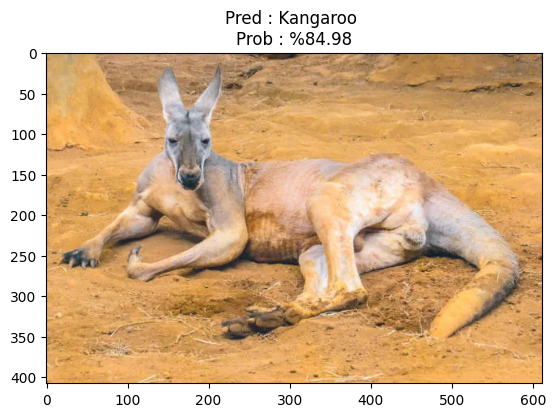

In [122]:
custom_image_path = data_path / "kangaroo.jpg"
transform_predict(model=model,
                  image_path=custom_image_path,
                  class_names=class_names,
                  transform=auto_transforms)

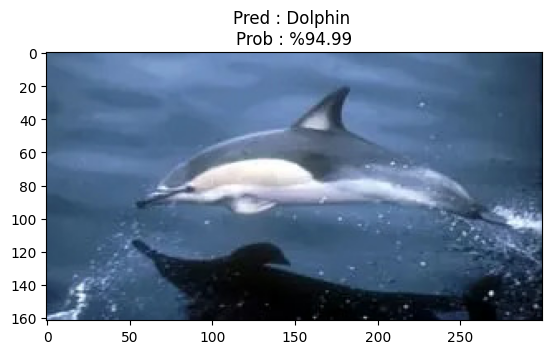

In [123]:
custom_image_path = data_path / "dolphin3.jpg"
transform_predict(model=model,
                  image_path=custom_image_path,
                  class_names=class_names,
                  transform=auto_transforms)